In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
import folium
from shapely.geometry import Polygon
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec

In [2]:
# Font sizes params
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.title_fontsize": 7
})

In [4]:
usage_mapping = {
    1000: "Wohngebäude",
    1010: "Wohnhaus",
    1020: "Wohngemeine",
    1100: "Gemischt genutztes Gebäude mit Wohnen",
    1120: "Wohngebäude mit Handel und Dienstleistungen",
    2010: "Gebäude für Handel und Dienstleistungen",
    2020: "Bürogebäude",
    2050: "Geschäftsgebäude",
    2120: "Werkstatt",
    2140: "Gebäude für Vorratshaltung",
    2310: "Gebäude für Handel und Dienstleistung mit Wohnen",
    2320: "Gebäude für Gewerbe und Industrie mit Wohnen",
    2463: "Garage",
    2465: "Tiefgarage",
}


WOHNGEBAEUDE = {
    1000,
    1010,
    1020,
}

MISCHGEBAEUDE = {
    1100,
    1110,
    1120,
    1130,
    1210,
    1220,
    2310,
    2320,
}

GEWERBEGEBAEUDE = {
    2010,
    2020,
    2050,
    2053,
    2060,
    2110,
    2112,
    2113,
    2120,
    2130,
    2131,
    2140,
    2150,
    2160,
    2213,
    
}

COLOR_MAP = {
    "Wohngebäude": "tab:green",
    "Mischgebäude": "tab:blue",
    "Gewerbegebäude": "tab:red",
    "Sonstige": "tab:gray",
}

quelle = "Freie und Hansestadt Hamburg, Landesbetrieb Geoinformation und Vermessung (LGV), dl-de/by-2-0(https://www.govdata.de/dl-de/by-2-0), URL=https://metaver.de/trefferanzeige?docuuid=DC71F8A1-7A8C-488C-AC99-23776FA7775E"

#default_bbox = [[10.045725448115505, 53.56373965563346],
#               [10.04483158296414, 53.56928571310496],
#               [10.061462179332965, 53.574146646448916],
#               [10.064284911389908, 53.56640800076195]]
default_bbox = [[10.071450882096563, 53.57343719771864],
               [10.078282200812708, 53.57582089436743],
               [10.086978353249249, 53.57780085497406],
               [10.088500780178016, 53.57786434031859],
               [10.08968943613927, 53.57528776626812],
               [10.090770539267197, 53.57544358156409],
               [10.09161951641922, 53.57351782519276],
               [10.081990170144394, 53.57132713390438],
                [10.07602700765947, 53.571645156140086],
                [10.07573490367003, 53.5721943741919],
                [10.072668065541466, 53.57226654319956]]

In [14]:
def limit_gdf(base_gdf: gpd.GeoDataFrame, limiting_gdf: gpd.GeoDataFrame):
    limiting_geom = limiting_gdf.geometry.iloc[0]
    limited_gdf = base_gdf[base_gdf.geometry.intersects(limiting_geom)].copy()
    #limited_gdf = limited_gdf.reset_index(drop=True)
    #print("Shape of limited gdf: ", limited_gdf.shape)
    #print(filtered_buildings_gdf.head())
    return limited_gdf

def plot_with_border(base_gdf: gpd.GeoDataFrame, border_gdf: gpd.GeoDataFrame):
    ax = base_gdf.plot(figsize=(10, 10), edgecolor="black", facecolor="none")
    border_gdf.boundary.plot(ax=ax, color="red")

def classify_building_type(code):
    """
    Params: 
        code, int:   ALKIS gebäudefunktion code 
    Returns:
        string: building type based on predefined sets of ALKIS codes
    """
    if pd.isna(code):
        return "Sonstige"
    code = int(code)

    if code in WOHNGEBAEUDE:
        return "Wohngebäude"
    if code in MISCHGEBAEUDE:
        return "Mischgebäude"
    if code in GEWERBEGEBAEUDE:
        return "Gewerbegebäude"

    return "Sonstige"

def add_building_category(gdf):
    result = gdf.copy()
    result["building_type"] = (result["gebaeudefunktion"].apply(classify_building_type))

    return result



def plot_building_type_map(buildings_gdf, border_gdf=None, ax=None, title=None):

    if ax is None:
        figsize=(12, 6)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
    
    total = len(buildings_gdf)

    # IMPORTANT: basemap requires Web Mercator
    buildings_plot = buildings_gdf.to_crs(epsg=3857)

    if border_gdf is not None:
        border_plot = border_gdf.to_crs(epsg=3857)


    for category, color in COLOR_MAP.items():
        subset = buildings_plot[buildings_plot["building_type"] == category]

        if len(subset) > 0:
            subset.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.2,
                alpha=0.7
            )

    if border_gdf is not None:
        border_plot.boundary.plot(
            ax=ax,
            color="black",
            linewidth=2
        )

    # --- BASEMAP (CartoDB Positron-like) ---
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=16)

    legend_elements = []

    for category in COLOR_MAP:
        count = (buildings_gdf["building_type"] == category).sum()
        percentage = 100 * count / total
        legend_elements.append(Patch(facecolor=COLOR_MAP[category], label=f"{category}: {count} ({percentage:.1f}%)"))

    if title is not None:
        ax.set_title(title)    
    ax.legend(
        handles=legend_elements,
        title="Gebäudetypen",
        loc="lower right",
        #bbox_to_anchor=(0.01, 0.01),
        #fontsize=6,
        #framealpha=0.9
    )
    ax.set_axis_off()

    return fig, ax
    
def plot_construction_year_histogram(buildings_gdf, bins=20, ax=None):

    if ax is None:
        figsize=(12, 6)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
        
    valid = buildings_gdf.dropna(subset=["baujahr"])

    datasets = []
    labels = []
    colors = []

    for category, color in COLOR_MAP.items():
        subset = valid[valid["building_type"] == category]
        
        if len(subset) == 0:
            continue

        datasets.append(subset["baujahr"])
        labels.append(category)
        colors.append(color)

    ax.hist(
        datasets,
        bins=bins,
        stacked=True,
        label=labels,
        color=colors
    )

    ax.set_title("Verteilung der bekannten Baujahren")
    ax.set_xlabel("Baujahr")
    ax.set_ylabel("Anzahl Gebäude")
    ax.legend()

    return fig, ax


def plot_area_distribution(buildings_gdf, area_column, area_label, building_type="Sonstige", top_n=None, ax=None):

    subset = buildings_gdf[buildings_gdf["building_type"] == building_type].copy()
    subset = subset.dropna(subset=[area_column])
    subset = subset.sort_values(area_column, ascending=False)

    color = COLOR_MAP[building_type]

    if top_n:
        subset = subset.head(top_n)

    if ax is None:
        figsize=(12, 6)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    ax.bar(range(len(subset)), subset[area_column], color=color)
    ax.set_title(f"{building_type} - {area_label}")
    ax.set_xlabel("Gebäude")
    ax.set_ylabel(f"{area_label} [m²]")

    return fig, ax


def plot_roof_area_distribution(buildings_gdf, area_column, area_label, top_n=None, ax=None):

    subset = buildings_gdf[buildings_gdf["area"] != 0].copy()
    subset = subset.dropna(subset=[area_column])
    subset = subset.sort_values(area_column, ascending=False)

    color = "tab:orange"

    if top_n:
        subset = subset.head(top_n)

    if ax is None:
        figsize=(12, 6)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    ax.bar(range(len(subset)), subset[area_column], color=color)
    ax.set_title(f"{area_label}")
    ax.set_xlabel("Gebäude")
    ax.set_ylabel(f"{area_label} [m²]")

    return fig, ax

def generate_a4_report(buildings_gdf, border_gdf=None, footprint_area_column="grundflaeche", roof_area_column="usable_roof_area", title="Quartieranalyse"):

    fig = plt.figure(figsize=(8.27, 11.69))
    gs = GridSpec(nrows=5, ncols=2, figure=fig, height_ratios=[3.0, 1.5, 1.0,1.0,1.0])

    # map

    ax_map = fig.add_subplot(gs[0, :])
    plot_building_type_map(buildings_gdf, border_gdf, ax=ax_map, title=title)

    # construction years

    ax_year = fig.add_subplot(gs[1, :])
    plot_construction_year_histogram(buildings_gdf, ax=ax_year)

    # footprint distributions

    # Need to atomate it like other plots
    building_types = [
        "Wohngebäude",
        "Mischgebäude",
        "Gewerbegebäude"
    ]

    for row, building_type in enumerate(building_types):
        ax = fig.add_subplot(gs[row + 2, 0])
        plot_area_distribution(buildings_gdf, building_type, footprint_area_column, "Grundfläche", ax=ax)

    # roof distributions

    for row, building_type in enumerate(building_types):
        ax = fig.add_subplot(gs[row + 2, 1])
        plot_area_distribution(buildings_gdf, building_type, roof_area_column, "Nutzbare Dachfläche", ax=ax)

    plt.tight_layout()

    return fig

def generate_a4_report_simple_solar(buildings_gdf, buildings_solar_gdf, border_gdf=None, footprint_area_column="grundflaeche", roof_area_column="usable_roof_area", title="Quartieranalyse"):

    fig = plt.figure(figsize=(8.27, 11.69))
    gs = GridSpec(nrows=5, ncols=2, figure=fig, height_ratios=[3.0, 1.5, 1.0,1.0,1.0])

    # map

    ax_map = fig.add_subplot(gs[0, :])
    plot_building_type_map(buildings_gdf, border_gdf, ax=ax_map, title=title)

    # construction years

    ax_year = fig.add_subplot(gs[1, :])
    plot_construction_year_histogram(buildings_gdf, ax=ax_year)

    # footprint distributions

    # Need to atomate it like other plots
    building_types = [
        "Wohngebäude",
        "Mischgebäude",
        "Gewerbegebäude"
    ]

    for row, building_type in enumerate(building_types):
        ax = fig.add_subplot(gs[row + 2, 0]) 
        plot_area_distribution(buildings_gdf=buildings_gdf, building_type=building_type, area_column=footprint_area_column, area_label="Grundfläche", ax=ax)

    # roof distributions
    ax = fig.add_subplot(gs[2, 1])
    plot_roof_area_distribution(buildings_gdf=buildings_solar_gdf, area_column=roof_area_column, area_label="Nutzbare Dachfläche", ax=ax)

    plt.tight_layout()

    return fig

def build_report(border_coordinates: list, title: str=None, save_file: str=None):
    border_poly = Polygon(border_coordinates)
    border_gdf = gpd.GeoDataFrame(geometry=[border_poly], crs="EPSG:4326")
    buildings_gdf = gpd.read_parquet("buildings.parquet")
    buildings_gdf = buildings_gdf.to_crs("EPSG:4326")
    
    buildings_solar_gdf = gpd.read_parquet("buildings_solar_with_geometry.parquet")
    buildings_solar_gdf = buildings_solar_gdf.to_crs("EPSG:4326")

    limited_gdf = limit_gdf(buildings_gdf, border_gdf)
    report_solar_gdf = limit_gdf(buildings_solar_gdf, border_gdf)

    report_gdf = add_building_category(limited_gdf)
    
    fig = generate_a4_report_simple_solar(report_gdf, report_solar_gdf, title=title)
    if save_file is not None:
        fig.savefig(save_file, dpi=300, bbox_inches="tight")

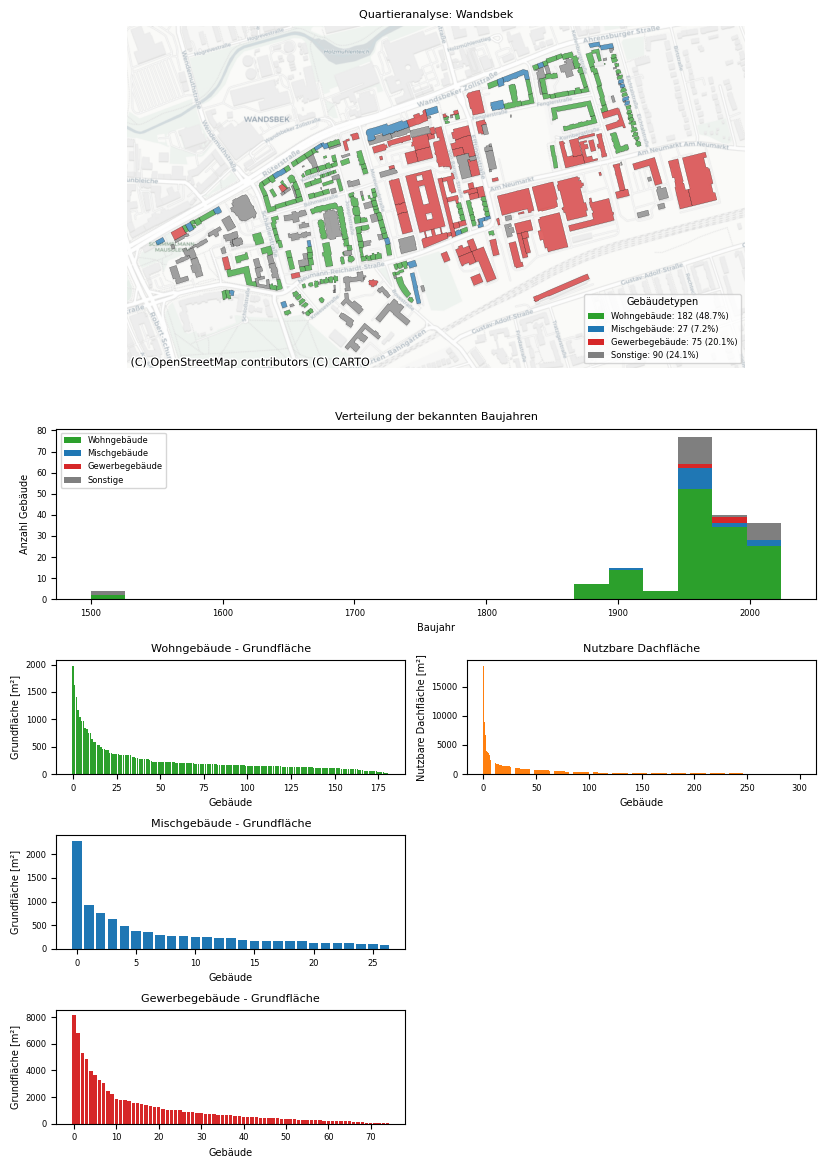

In [15]:
inspection_area = [[10.071450882096563, 53.57343719771864],
               [10.078282200812708, 53.57582089436743],
               [10.086978353249249, 53.57780085497406],
               [10.088500780178016, 53.57786434031859],
               [10.08968943613927, 53.57528776626812],
               [10.090770539267197, 53.57544358156409],
               [10.09161951641922, 53.57351782519276],
               [10.081990170144394, 53.57132713390438],
                [10.07602700765947, 53.571645156140086],
                [10.07573490367003, 53.5721943741919],
                [10.072668065541466, 53.57226654319956]]

build_report(inspection_area, title="Quartieranalyse: Wandsbek", save_file="building_report.pdf")

In [ ]:
def plot_wit_data(base_gdf: gpd.GeoDataFrame, border_gdf: gpd.GeoDataFrame) -> None:
    base_gdf["usage"] = (base_gdf["gebaeudefunktion"].map(usage_mapping).fillna("Sonstige"))
    
    fig, ax = plt.subplots(figsize=(12, 12))

    base_gdf.plot(
        column="usage",
        legend=True,
        categorical=True,
        ax=ax
    )
    
    border_gdf.boundary.plot(
        ax=ax,
        color="black",
        linewidth=2
    )

    plt.title("Gebäudenutzung")
    plt.show()

def plot_construction_year_histogram_simple(base_gdf: gpd.GeoDataFrame) -> None: 
    years = base_gdf["baujahr"].dropna()

    bins = np.arange(years.min()//10*10, years.max()+10, 10)
    
    plt.figure(figsize=(12,6))
    plt.hist(years, bins=bins)
    plt.xlabel("Baujahr")
    plt.ylabel("Gebäudeanzahl")
    plt.title("Baujahrverteilung")
    plt.show()

In [ ]:
border_poly = Polygon(border_coordinates)
border_gdf = gpd.GeoDataFrame(geometry=[border_poly], crs="EPSG:4326")
buildings_gdf = gpd.read_parquet("buildings.parquet")
buildings_gdf = buildings_gdf.to_crs("EPSG:4326")
    
buildings_solar_gdf = gpd.read_parquet("buildings_solar_with_geometry.parquet")
buildings_solar_gdf = buildings_solar_gdf.to_crs("EPSG:4326")

limited_gdf = limit_gdf(buildings_gdf, border_gdf)
report_solar_gdf = limit_gdf(buildings_solar_gdf, border_gdf)

plot_wit_data(limited_gdf, border_gdf)
plot_construction_year_histogram_simple(limited_gdf)
#plot_with_border(limited_gdf, def_poly_gdf)

limited_gdf["gebaeudefunktion"].value_counts()
limited_gdf["gebaeudefunktion"].unique()

inspection_area = border_gdf.to_crs("EPSG:25832")
total_area = inspection_area.geometry.iloc[0].area
print("Fläche in m*2: ", total_area)

num_buildings = len(limited_gdf)
print("Anzahl Gebäude: ", num_buildings)
known_years = limited_gdf["baujahr"].notna().sum()
known_year_share = known_years / num_buildings * 100
print(f"Baujahr Vollständigkeit: {known_year_share:.2f}")